170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0237 - mae: 0.0976 - val_loss: 0.0053 - val_mae: 0.0497
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0041 - mae: 0.0435 - val_loss: 0.0018 - val_mae: 0.0292
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0011 - mae: 0.0222 - val_loss: 3.3707e-04 - val_mae: 0.0131
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 1.4420e-04 - mae: 0.0085 - val_loss: 8.3763e-05 - val_mae: 0.0068
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 7.3141e-05 - mae: 0.0064 - val_loss: 5.5503e-05 - val_mae: 0.0055
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


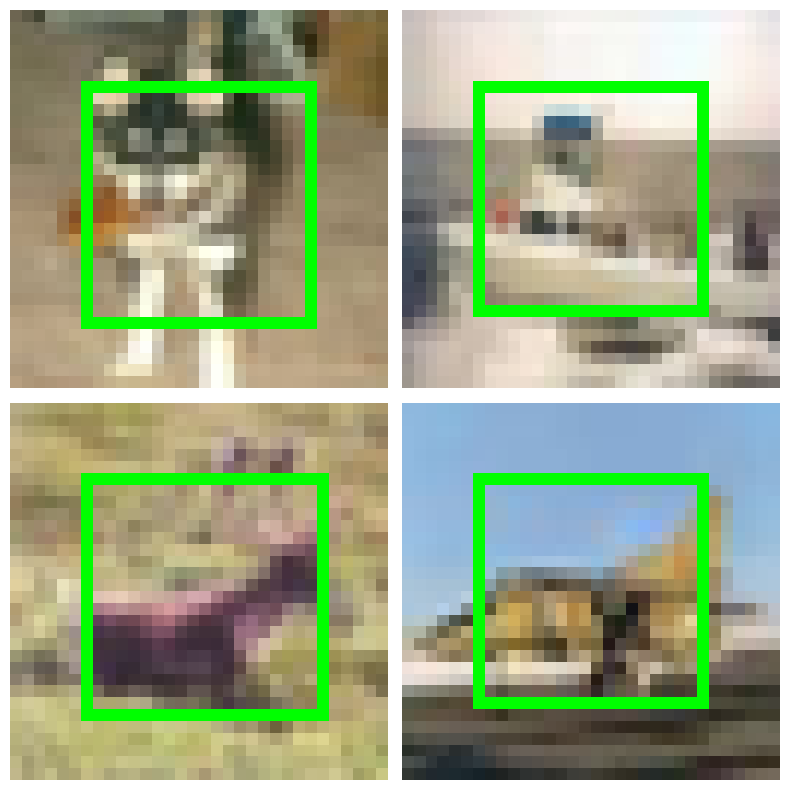

In [2]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

# Load Dataset
(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()

# Pre-processing
# Selecting a subset for demonstration as per the notes
X = X_train_full[:2000]
y_class = y_train_full[:2000]
X = X / 255.0  # Normalizing

# Defining dummy bounding boxes for the experiment (as noted in your code)
y_bbox = np.array([[0.2, 0.2, 0.8, 0.8] for _ in range(len(X))])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_bbox, test_size=0.2, random_state=42)

# Build CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(4) # Output 4 values for the bounding box (xmin, ymin, xmax, ymax)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

# Predict and Visualize
predictions = model.predict(X_test)
plt.figure(figsize=(8, 8))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    img = X_test[i].copy()
    h, w, _ = img.shape

    # Extract predicted coordinates
    xmin_p, ymin_p, xmax_p, ymax_p = predictions[i]

    # Scale coordinates back to image size
    start_point = (int(xmin_p * w), int(ymin_p * h))
    end_point = (int(xmax_p * w), int(ymax_p * h))

    # Draw rectangle (Green box)
    # Note: OpenCV uses BGR, but since we use plt.imshow, we treat it as RGB
    cv2.rectangle(img, start_point, end_point, (0, 255, 0), 1)

    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()